In [200]:
# ! pip install shap==0.50.0

In [201]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef
from sklearn.datasets import fetch_openml
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
import matplotlib.pyplot as plt
import shap
shap.initjs() # Inicjalizacja JS dla wizualizacji SHAP

# Wstęp

Kilka zajęć temu wprowadziliśmy **modele drzewiaste**, a w tym model **XGBoost**. Skupialiśmy się wtedy głównie na tym, *jak trenować model* oraz *jak oceniać jego jakość predykcji*.  

Na dzisiejszych zajęciach zmienimy perspektywę i spróbujemy odpowiedzieć na inne, równie ważne pytanie:

> **Czego właściwie nauczył się model?**

Innymi słowy — postaramy się **zinterpretować decyzje modelu**, zrozumieć, które cechy mają największy wpływ na predykcję oraz w jaki sposób wpływają one na wynik dla pojedynczej obserwacji.

Do tego celu wykorzystamy **wartości Shapleya (SHAP)**, a wszystkie przykłady przeprowadzimy na klasycznym zbiorze danych **Titanic**.

---

# Zbiór danych Titanic

Zbiór danych Titanic opisuje pasażerów statku RMS Titanic i zawiera informacje, które pozwalają przewidywać, czy dana osoba **przeżyła katastrofę**.

## Opis kolumn

| Nazwa kolumny | Opis |
|:--------------|:-------------------------------------------------------------|
| **PassengerId** | Unikalny identyfikator pasażera. |
| **Survived** | Informacja czy pasażer przeżył (1 = przeżył, 0 = nie przeżył). |
| **Pclass** | Klasa biletu pasażera (1 = pierwsza klasa, 2 = druga klasa, 3 = trzecia klasa). |
| **Name** | Imię i nazwisko pasażera. |
| **Sex** | Płeć pasażera (`male` lub `female`). |
| **Age** | Wiek pasażera w latach. |
| **SibSp** | Liczba rodzeństwa i/lub małżonków, którzy podróżowali z pasażerem. |
| **Parch** | Liczba rodziców i/lub dzieci, którzy podróżowali z pasażerem. |
| **Ticket** | Numer biletu. |
| **Fare** | Cena biletu (w funtach brytyjskich). |
| **Cabin** | Numer kabiny pasażera. |
| **Embarked** | Port, z którego pasażer wsiadł na statek (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton). |

---

# Interpretowalność modeli a wartości Shapleya

Modele drzewiaste, takie jak **CatBoost**, **XGBoost** czy **Random Forest**, często osiągają bardzo dobre wyniki, ale są jednocześnie uznawane za **modele typu „black-box”** — trudno jest jednoznacznie powiedzieć, dlaczego model podjął konkretną decyzję.

Jednym z najbardziej popularnych i teoretycznie uzasadnionych sposobów interpretacji takich modeli są **wartości Shapleya (Shapley values)**.

---

## Intuicja stojąca za wartościami Shapleya

Wartości Shapleya pochodzą z **teorii gier kooperacyjnych**.  

Wyobraźmy sobie grę, w której:
- gracze wspólnie pracują na osiągnięcie wyniku,
- a nagrodę końcową trzeba sprawiedliwie podzielić pomiędzy nich.

W kontekście uczenia maszynowego:
- **graczami** są cechy (np. `Age`, `Sex`, `Fare`),
- **wynikiem gry** jest predykcja modelu,
- **nagrodą** jest odchylenie predykcji od wartości bazowej (np. średniej predykcji modelu).

Wartość Shapleya dla danej cechy mówi nam:

> **jaki był średni wkład tej cechy do predykcji modelu, uśredniony po wszystkich możliwych kombinacjach pozostałych cech.**

---

## Formalna idea (bez wchodzenia w dowody)

Dla pojedynczej obserwacji:
- model zaczyna od **wartości bazowej** (np. średniego prawdopodobieństwa przeżycia),
- każda cecha **dokłada lub odejmuje** pewną wartość,
- suma wartości Shapleya wszystkich cech daje końcową predykcję modelu.

Można to zapisać w uproszczonej postaci:

predykcja = wartość bazowa + suma wartości Shapleya cech

Dzięki temu SHAP pozwala nam odpowiedzieć zarówno na pytania:
- *które cechy są najważniejsze globalnie?*  
- *dlaczego model podjął taką decyzję dla konkretnego pasażera?*

---

W dalszej części notebooka:
- wytrenujemy model **XGBoost**,
- obliczymy wartości SHAP,
- przeanalizujemy zarówno **globalne**, jak i **lokalne** wyjaśnienia predykcji modelu.


# Przygotowanie danych

In [203]:
data = fetch_openml(name='titanic', version=1, as_frame=True)
df = data.frame
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


**Proszę:**
- Usuń kolumny, które nie nadają się jako cecha do klasyfikacji
- Usuń wiersze z brakującymi wartościami
- Zamień dane kategoryczne na liczbowe, ale zachowaj informacje o mapowaniu z kategorii na liczby (aby móc interpretować cechy)
- Podziel zbiór na testowy i treningowy (X_train, y_train, X_test, y_test)

In [204]:
df.drop(columns=['ticket', 'name', 'cabin', 'boat', 'body', 'home.dest'], inplace=True)
df.dropna(inplace=True)
print(len(df))
category_mappings = {}
# Zamiana kolumn kategorycznych (string) na wartości liczbowe
for col in df.select_dtypes(include=["object", "category"]).columns:
    category_mappings[col] = dict(enumerate(df[col].cat.categories))
    df[col] = df[col].astype("category").cat.codes

print(category_mappings)
df_train, df_test = train_test_split(df, test_size=0.3, random_state=9869, stratify=df['survived'])


X_train = df_train.drop(columns=['survived']).reset_index(drop=True)
y_train = df_train['survived'].reset_index(drop=True)
X_test = df_test.drop(columns=['survived']).reset_index(drop=True)
y_test = df_test['survived'].reset_index(drop=True)

1043
{'survived': {0: '0', 1: '1'}, 'sex': {0: 'female', 1: 'male'}, 'embarked': {0: 'C', 1: 'Q', 2: 'S'}}


,pclass,survived,sex,age,sibsp,parch,fare,embarked
140,3,1,0,0.1667,1,2,20.5750,2
16,3,0,1,0.3333,0,2,14.4000,2
252,3,1,1,0.4167,0,1,8.5167,0
172,3,1,0,0.7500,2,1,19.2583,0
34,2,1,1,0.8333,0,2,29.0000,2
174,3,0,0,1.0000,1,1,12.1833,2
6,3,0,1,2.0000,4,1,29.1250,1
17,3,0,0,2.0000,0,1,10.4625,2
264,2,1,1,2.0000,1,1,23.0000,2
245,2,1,0,2.0000,1,1,26.0000,2


# Analiza korelacji
**Proszę:** Zbadaj jak wyglądają korelacje naszych kolumn. Może to być przydatne w dalszej części analiz.

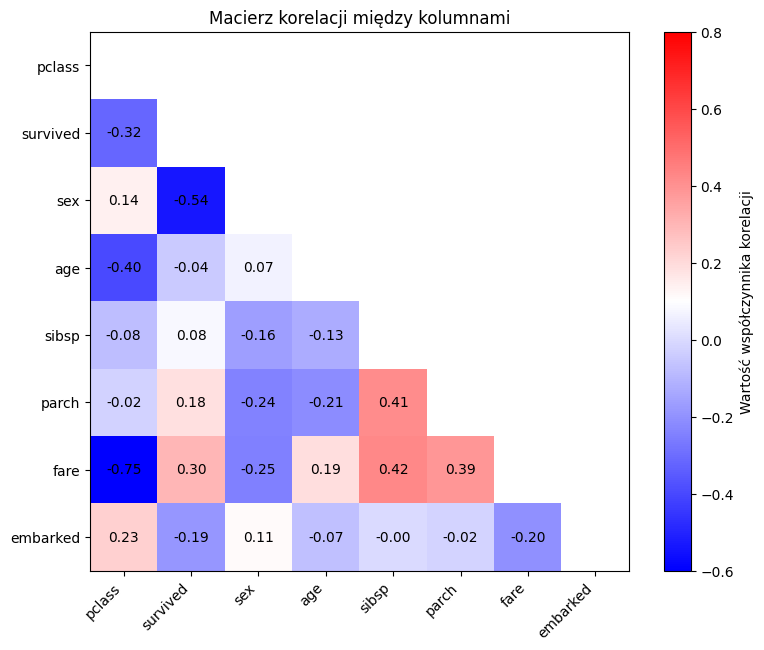

In [205]:
corr_matrix = df.corr(method='spearman').values # Wybieramy korelację Spearmana, ponieważ mamy dane numeryczne i kategoryczne


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # maska górnej części

plt.figure(figsize=(9, 7))
plt.title('Macierz korelacji między kolumnami')

corr_masked = np.ma.array(corr_matrix, mask=mask)

plt.imshow(corr_masked, cmap='bwr', vmin=-0.6, vmax=0.8)
columns = df.columns
plt.xticks(range(len(columns)), columns, rotation=45, ha='right') 
plt.yticks(range(len(columns)), columns)
# Dodać wartości korelacji do rysunka
for i in range(len(columns)):
    for j in range(len(columns)):
        if not mask[i, j]:
            plt.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color='black', fontdict={'size': 10})

plt.colorbar(label='Wartość współczynnika korelacji')
plt.show()


# Trening modelu
**Proszę:**
- Wytrenuj model 'GradientBoostingClassifier'
- Oblicz metrykę 'matthews_corrcoef' na zbiorze testowym

In [206]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mcc = matthews_corrcoef(y_test, y_pred)
print(f'Matthews correlation coefficient: {mcc:.4f}')

Matthews correlation coefficient: 0.5033


# Inicjalizacja modułu SHAP i dwa sposoby wyznaczania wartości SHAP

W przypadku obliczania wartości SHAP dla modeli drzewiastych mamy do wyboru różne strategie określające, **w jaki sposób traktować zależności (korelacje) pomiędzy cechami**.  
Jest to istotne, ponieważ wartości SHAP opierają się na **wartościach oczekiwanych warunkowych**.

Parametr `feature_perturbation` może przyjmować następujące wartości:

- `"auto"` (domyślne)
- `"interventional"`
- `"tree_path_dependent"`

---

## `feature_perturbation="interventional"`

W tym podejściu:
- wymagany jest **zbiór danych tła (background dataset)**,
- zależności pomiędzy cechami są modelowane zgodnie z zasadami **wnioskowania przyczynowego (causal inference)**,
- przy „wyłączaniu” danej cechy jej wartość jest zastępowana wartościami ze zbioru tła, niezależnie od pozostałych cech.

Własności praktyczne:
- czas obliczeń skaluje się **liniowo z liczbą próbek w zbiorze tła**,
- typowo stosuje się od **100 do 1000 losowych próbek** jako sensowny kompromis między jakością a czasem obliczeń,
- podejście to jest bardziej poprawne teoretycznie w obecności silnych zależności między cechami, ale droższe obliczeniowo.

**Ograniczenie praktyczne:**  
Dla modeli drzewiastych wykorzystujących **natywną obsługę cech kategorycznych** (np. `CatBoostClassifier`) tryb `"interventional"` **nie jest wspierany** przez `TreeExplainer`.

---

## `feature_perturbation="tree_path_dependent"`

W tym podejściu:
- **nie jest wymagany zbiór danych tła**,
- algorytm podąża wyłącznie ścieżkami drzew,
- rozkład tła jest aproksymowany przez **liczbę przykładów treningowych, które trafiały do poszczególnych liści drzew**.

Własności praktyczne:
- bardzo szybkie obliczenia,
- naturalnie dopasowane do modeli drzewiastych,
- zakłada, że struktura drzew dobrze odzwierciedla zależności w danych.

---

W praktyce:
- `"auto"` może prowadzić do niejednoznacznego wyboru metody i błędów przy modelach z cechami kategorycznymi,
- `"tree_path_dependent"` jest często wybierane ze względu na szybkość i brak konieczności definiowania zbioru tła,
- `"interventional"` daje większą kontrolę nad interpretacją w przypadku silnie skorelowanych cech.

**Uwaga dla tego notebooka:**  
Zbiór danych Titanic jest stosunkowo mały i zawiera cechy skorelowane, więc warto wykorzystać metodę `"interventional"`. Do tego celu na początku zamieniliśmy dane kategoryczne na liczbowe.


In [207]:
explainer = shap.TreeExplainer(model, feature_perturbation="interventional", feature_names=X_test.columns, data=X_test, model_output="probability")

## Przyjrzyjmy się co dokładnie kryje się w obiekcie 'shap_values'
Jest to obiekt, który łączy w sobie wartości SHAP oraz wszystkie informacje potrzebne do ich interpretacji i wizualizacji. Najważniejsze atrybuty obiektu `shap_values`:
- **`values`** – właściwe wartości SHAP: każda wartość mówi, **jak bardzo dana cecha przesunęła predykcję modelu w górę lub w dół** dla konkretnej obserwacji
- **`base_values`** – wartość bazowa modelu: najczęściej jest to **średnia predykcja modelu na zbiorze tła**, dla klasyfikacji binarnej zwykle jest to **logit lub prawdopodobieństwo bazowe**
- **`data`** – dane wejściowe, dla których obliczono SHAP: odpowiada dokładnie `X_test`


In [208]:
shap_values = explainer(X_test)
shap_values

.values =
array([[-0.00798443, -0.22485483, -0.02032421, ...,  0.00228976,
         0.0035618 , -0.03339923],
       [ 0.09823201, -0.22230025,  0.02176908, ...,  0.00106753,
        -0.03734075, -0.02101425],
       [-0.09941362,  0.42123435,  0.02833727, ..., -0.00061688,
         0.05397932,  0.06752807],
       ...,
       [-0.07299867, -0.13186463, -0.00058982, ...,  0.00199091,
        -0.07274019, -0.02606558],
       [-0.17875546,  0.25192623,  0.00346754, ..., -0.00730613,
        -0.15850749,  0.06405213],
       [-0.07469445, -0.13468047, -0.00235362, ...,  0.00206813,
        -0.03260087, -0.04048527]])

.base_values =
array([0.41008909, 0.41008909, 0.41008909, 0.41008909, 0.41008909,
       0.41008909, 0.41008909, 0.41008909, 0.41008909, 0.41008909,
       0.41008909, 0.41008909, 0.41008909, 0.41008909, 0.41008909,
       0.41008909, 0.41008909, 0.41008909, 0.41008909, 0.41008909,
       0.41008909, 0.41008909, 0.41008909, 0.41008909, 0.41008909,
       0.41008909, 0.41008

# Wyjaśnienia globalne
Zadajmy sobie pytanie: **na czym model opiera swoje decyzje w skali całego zbioru danych?**

## Wykres typu beeswarm – jak go interpretować?

### Oś Y – cechy
- Każdy wiersz odpowiada jednej cesze.
- Cechy są posortowane od góry do dołu według **średniej bezwzględnej wartości SHAP**.
- Im wyżej znajduje się cecha, tym **większy globalny wpływ** ma ona na decyzje modelu.

### Oś X – wartości SHAP
- Wartość SHAP mówi, **jak bardzo dana cecha zmienia predykcję modelu**:
  - wartości dodatnie → zwiększają prawdopodobieństwo przeżycia,
  - wartości ujemne → zmniejszają prawdopodobieństwo przeżycia.
- Im dalej punkt znajduje się od zera, tym **silniejszy wpływ** cechy.

### Punkty – pojedyncze obserwacje
- Każda kropka reprezentuje **jednego pasażera**.
- Rozrzut punktów pokazuje, że **ta sama cecha może działać różnie** dla różnych osób.

### Kolor – wartość cechy
- Kolor punktu odpowiada **rzeczywistej wartości cechy**:
  - kolor niebieski oznacza niską wartość,
  - kolor czerwony – wysoką wartość.
- Dzięki temu możemy zauważyć zależności typu:
  - „wysoka wartość cechy zwiększa szansę przeżycia”,
  - lub „niska wartość cechy działa na korzyść pasażera”.

W skrócie:  
**beeswarm pokazuje, które cechy są ważne, jak działają i dla kogo działają najmocniej.**


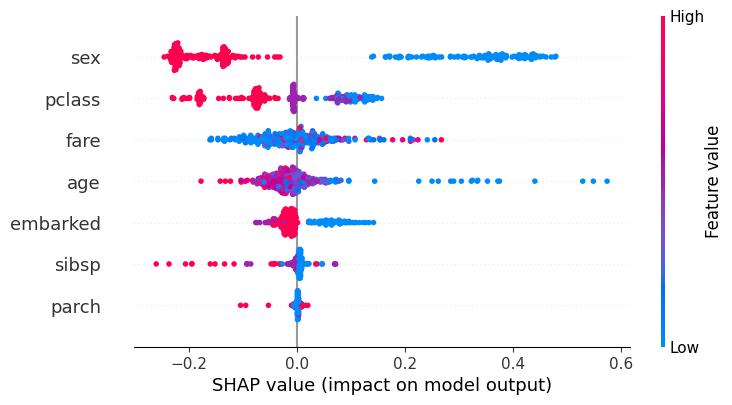

In [209]:
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

# Wyjaśnienia lokalne – decyzja modelu dla pojedynczej osoby

Do tej pory analizowaliśmy **wpływ cech w skali całego zbioru danych** – czyli wyjaśnienia globalne.  
Teraz przyjrzymy się, jak model podejmuje decyzje **dla konkretnego pasażera**, uwzględniając jednocześnie **interakcje między cechami**.

---

## Przykład: 9-letnia Ania podróżująca trzecią klasą

Chcemy sprawdzić, **które cechy decydują o przewidywanym prawdopodobieństwie przeżycia** Ani, które wynosi 0.305.

---

### Jak działa lokalna analiza SHAP?

1. Dla pojedynczej obserwacji zaczynamy od **wartości bazowej modelu** – średniego prawdopodobieństwa przeżycia w zbiorze danych.
2. SHAP oblicza wpływ każdej cechy poprzez tzw. **wartości oczekiwane warunkowe**:
   - dla danej cechy model pyta: *jak zmieniłaby się predykcja, gdyby znał tylko tę wartość, a wszystkie pozostałe cechy byłyby rozproszone zgodnie z rozkładem danych lub strukturą drzew?*
3. Wartość SHAP dla cechy mówi, **o ile dana cecha zwiększa lub zmniejsza prawdopodobieństwo przeżycia**, uwzględniając kontekst pozostałych cech.
4. Analizując kolejne cechy, możemy zauważyć **interakcje** – np. wpływ liczby rodzeństwa różni się w zależności od wieku:
   - dziecko w bez rodzeństwa → wyższa szansa przeżycia,
   - dziecko z trójką rodzeństwa → szansa mniejsza, mimo tego samego wieku.
5. Warto zauważyć, że sama korelacja między liczbą rodzeństwa a przetrwaniem jest bliska zeru, mimo widocznego wpływu dla dzieci, więc analiza korelacji nie powinna stanowić jedynej metody do analizy cech.

---

### Intuicja

- Wartości SHAP można wyobrazić sobie jako „głosy” każdej cechy dla danej decyzji:  
  - dodatnie wartości → zwiększają szansę na przeżycie,  
  - ujemne wartości → zmniejszają szansę na przeżycie.
- Proces ten powtarzamy dla wszystkich cech w obserwacji.
- Dzięki temu możemy powiedzieć:
  - które cechy są **najważniejsze dla Ani**,
  - w jaki sposób **każda cecha zmienia prawdopodobieństwo przeżycia w kontekście innych cech**.


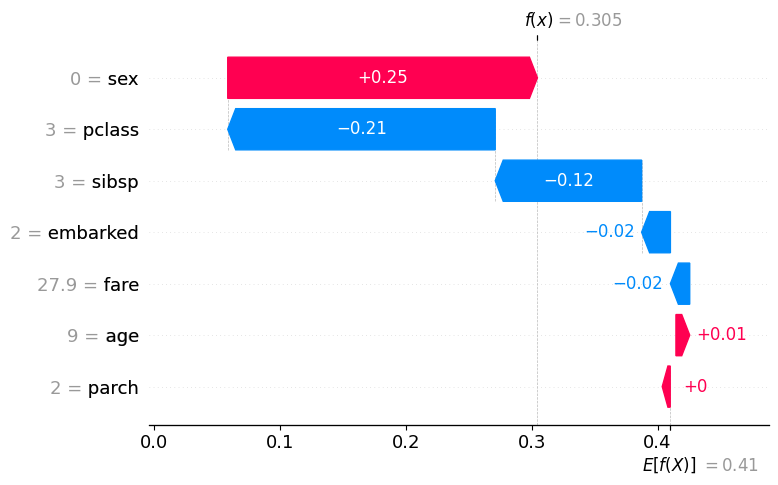

In [210]:
df_ania = X_test.iloc[[188]]
shap_values_ania = explainer(df_ania)
shap.plots.waterfall(shap_values_ania[0])

Jaki wpływ by miała cecha `sibsp`, gdyby Ania była starsza?

/tmp/ipykernel_3873515/1444007887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ania['age'] = 30


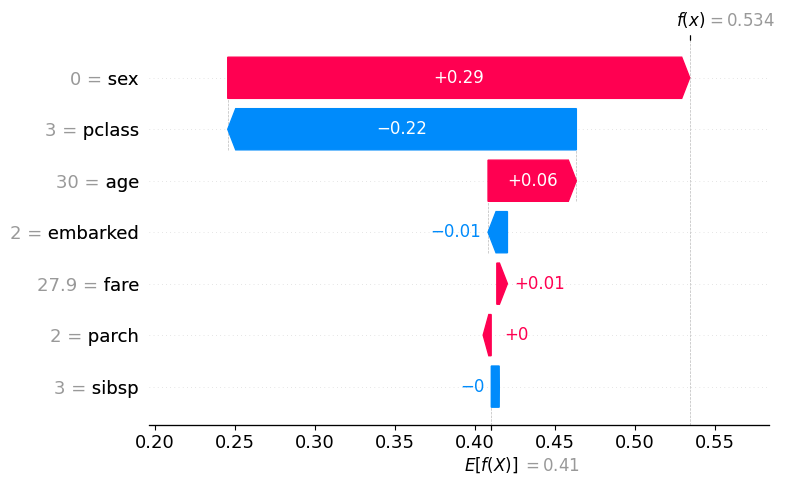

In [211]:
df_ania['age'] = 30
shap_values_ania = explainer(df_ania)
shap.plots.waterfall(shap_values_ania[0])

A gdyby Ania podróżowała pierwszą klasą?

/tmp/ipykernel_3873515/1165975952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ania['pclass'] = 1
/tmp/ipykernel_3873515/1165975952.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ania['fare'] = 150


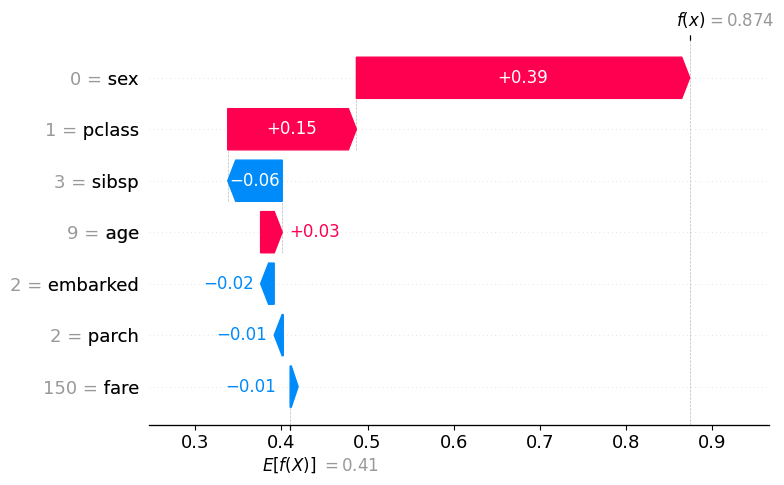

In [212]:
df_ania = X_test.iloc[[188]]
df_ania['pclass'] = 1
df_ania['fare'] = 150
shap_values_ania = explainer(df_ania)
shap.plots.waterfall(shap_values_ania[0])

# Ćwiczenie
Poniżej jest wczytany inny prosty zbiór danych, zawierający informacje o wysokości ubezpieczenia dla pewnej grupy osób.

**Proszę** przeprowadzić analizę analogiczną jak dla zbioru danych Titanic. Proszę znaleźć cechę, której istotność różni się w zależności on innej cechy.

**Wskazówka**: do predykcji wysokości ubezpieczenia użyj `GradientBoostingRegressor`

In [229]:
df = pd.read_csv("https://www.fuw.edu.pl/~mpoziomska/data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [246]:
df.dropna(inplace=True)
print(len(df))
for col in df.select_dtypes(include=["object", "category"]).columns:
    df[col] = df[col].astype("category").cat.codes

df_train, df_test = train_test_split(df, test_size=0.2, random_state=9869)


X_train = df_train.drop(columns=['charges']).reset_index(drop=True)
y_train = df_train['charges'].reset_index(drop=True)
X_test = df_test.drop(columns=['charges']).reset_index(drop=True)
y_test = df_test['charges'].reset_index(drop=True)

aa = df_test.copy().reset_index(drop=True)

model = GradientBoostingRegressor(random_state=42, loss='squared_error')
model.fit(X_train, y_train)
mse_loss = model.score(X_test, y_test)
print(f'R^2 score: {mse_loss:.4f}')

1338
R^2 score: 0.8135


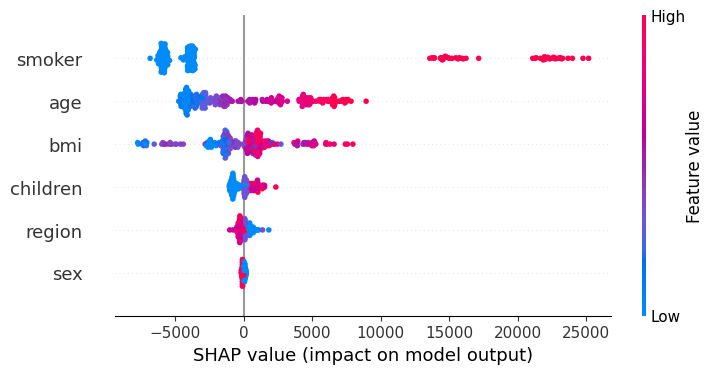

In [247]:
explainer = shap.TreeExplainer(model)

shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

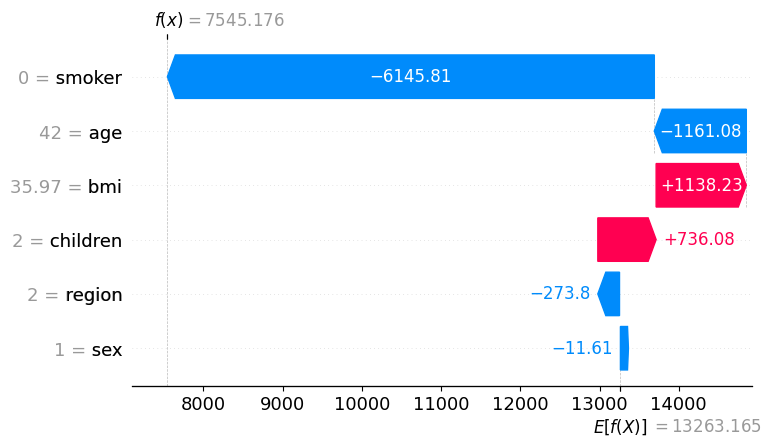

In [248]:
df_high_bmi = X_test.iloc[[55]]
shap_values_high_bmi = explainer(df_high_bmi)
shap.plots.waterfall(shap_values_high_bmi[0])

/tmp/ipykernel_3873515/2331331287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high_bmi['smoker'] = 1


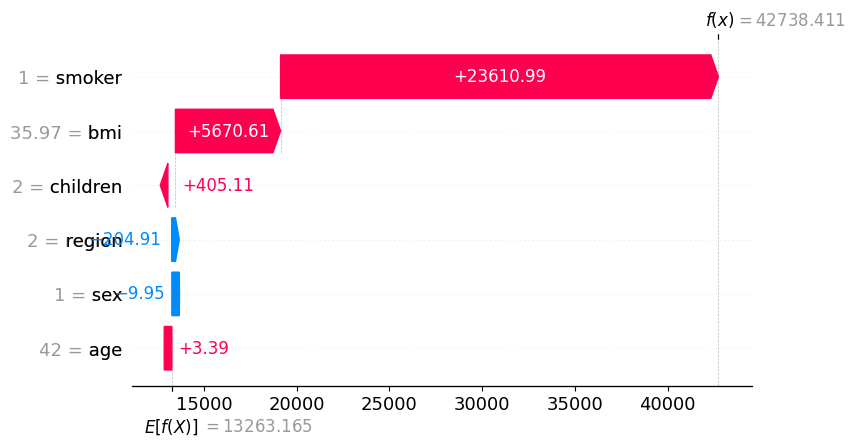

In [249]:
df_high_bmi['smoker'] = 1
shap_values_high_bmi = explainer(df_high_bmi)
shap.plots.waterfall(shap_values_high_bmi[0])